# Text analysis without trained models

Later in the course, we either use pre-trained models or models we trained ourselves for a corpus. Trained means, a statistical model is used for text analysis whose output depends on parameters that impact the model output. Before we use these more advanced techniques, we want to start with simpler approaches. Looking at our corpus, we want to aggregate the information in each document, usually by transforming it into a numerical representation. 

## Frequency based modeling

One of the easiest way to do this is to count the number of occurrences for every term in the document which ist listed in the lexicon. This approach is called bag-of-words which describes the fact we ignore the relationship of all words to each other and, hereby, loose semantic information. Let the number of documents be $n$ and the number of terms in the lexicon $d$, the corpus can be transformed to a document-term matrix $D$

$$
D = 
\begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1d} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \cdots & x_{nd} \\
\end{pmatrix}
$$

with $x_{ij}$ describing the number of term $j$ in document $i$. For larger corpora, $d$ is a large number so $D$ is a high-dimensional and, typically, sparse matrix which means the matrix has many zeros and only a few non-zero entries. A few options exist which can help dealing with this issue. One is the removal of stopwords. Other options are to exclude words with little and very high frequency or to exclude words with very little or high document occurrence. However, these measures need to be evaluated carefully, because sometimes words with little occurrence or frequency might provide more information than words with high occurrence of frequency. The bag-of-words approach can be conducted quite easily with the CountVectorizer class of the sklearn package. See a little demonstration in the following cells.

In [126]:
import sqlite3
import pandas as pd
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances, cosine_similarity
import pysentiment2 as ps
import numpy as np
import matplotlib.pylab as plt

In [2]:
# load Apple's 10-K filings
conn = sqlite3.connect("../data/dlta_texts.db")
sql_query = "SELECT * FROM filings;"
df_filings = pd.read_sql(sql_query, conn)
apple_filings = df_filings[df_filings.ticker == "AAPL"]
conn.close()
apple_filings.head(2)

,accessionNumber,filingDate,reportDate,acceptanceDateTime,act,form,fileNumber,filmNumber,items,size,isXBRL,isInlineXBRL,primaryDocument,primaryDocDescription,ticker,cik,text
0,0000320193-22-000108,2022-10-28,2022-09-24,2022-10-27T18:01:14.000Z,34,10-K,001-36743,221338448,,10332356,1,1,aapl-20220924.htm,10-K,AAPL,0000320193,10-K\n 1\n aapl-20220924.htm\n 10-K\n \n \n \n...
1,0000320193-21-000105,2021-10-29,2021-09-25,2021-10-28T18:04:28.000Z,34,10-K,001-36743,211359752,,10502096,1,1,aapl-20210925.htm,10-K,AAPL,0000320193,10-K\n 1\n aapl-20210925.htm\n 10-K\n \n \n \n...


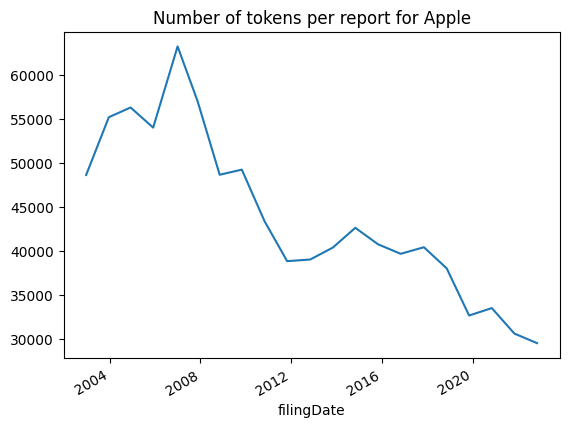

In [4]:
# a first check regarding the length of these reports
# import raw text
raw_reports = apple_filings.text.values
# preprocess each report
processed_reports = [simple_preprocess(report) for report in raw_reports]
# count the number of tokens for each report
nbr_words_per_report = [len(report) for report in processed_reports]
dates = pd.to_datetime(df_filings[df_filings.ticker == "AAPL"].filingDate)
words_per_report = pd.Series(index = dates, data = nbr_words_per_report)

# visualize the number of tokens per Apple report over time
fig, ax = plt.subplots()
words_per_report.plot(title = "Number of tokens per report for Apple", ax = ax)
plt.show()

Using the CountVectorizer with its default settings:

In [5]:
# create the bag-of-words with default settings
vectorizer = CountVectorizer(preprocessor = lambda x: " ".join(simple_preprocess(x)))
# the output is a sparse matrix, the first dimension are the number of reports, the second dimension is the number of terms
X = vectorizer.fit_transform(raw_reports)
# let us take a look at the first reports
feature_names = vectorizer.get_feature_names_out()
bow_default = pd.DataFrame(X.toarray(), index = dates, columns = feature_names)
bow_default.head()

,aac,aad,aapl,abandoned,abbett,abilities,ability,able,abnormal,abnormally,...,yo,york,yosemite,young,youtube,zayante,zero,zip,zones,zoom
filingDate,,,,,,,,,,,,,,,,,,,,,
2022-10-28,0,0,109,0,0,1,27,9,0,0,...,0,3,0,4,0,0,0,1,0,0
2021-10-29,0,0,130,0,0,1,26,10,0,0,...,0,2,0,3,0,0,0,1,0,0
2020-10-30,0,0,152,0,0,1,22,9,0,0,...,0,2,0,3,0,0,0,1,0,0
2019-10-31,0,0,116,0,0,1,19,9,0,0,...,0,2,0,3,0,0,0,1,0,0
2018-11-05,0,0,1,0,0,1,23,9,0,0,...,0,9,0,3,0,0,0,1,0,1


Using the CountVectorizer and deleting stopwords:

In [6]:
# import the stopword list from the gensim package
stopword_list = list(STOPWORDS)
stopword_list.sort()

# create the bag-of-words
vectorizer = CountVectorizer(preprocessor = lambda x: " ".join(simple_preprocess(x)), stop_words = stopword_list)
X = vectorizer.fit_transform(raw_reports)
# let us take a look at the first reports
feature_names = vectorizer.get_feature_names_out()
bow_wo_stopwords = pd.DataFrame(X.toarray(), index = dates, columns = feature_names)
bow_wo_stopwords.head()

,aac,aad,aapl,abandoned,abbett,abilities,ability,able,abnormal,abnormally,...,yo,york,yosemite,young,youtube,zayante,zero,zip,zones,zoom
filingDate,,,,,,,,,,,,,,,,,,,,,
2022-10-28,0,0,109,0,0,1,27,9,0,0,...,0,3,0,4,0,0,0,1,0,0
2021-10-29,0,0,130,0,0,1,26,10,0,0,...,0,2,0,3,0,0,0,1,0,0
2020-10-30,0,0,152,0,0,1,22,9,0,0,...,0,2,0,3,0,0,0,1,0,0
2019-10-31,0,0,116,0,0,1,19,9,0,0,...,0,2,0,3,0,0,0,1,0,0
2018-11-05,0,0,1,0,0,1,23,9,0,0,...,0,9,0,3,0,0,0,1,0,1


Using the CountVectorizer and restrict the counting to the top 100 features ordered by frequency across the corpus.

In [7]:
# create the bag-of-words
vectorizer = CountVectorizer(preprocessor = lambda x: " ".join(simple_preprocess(x)), stop_words = stopword_list, max_features = 100)
X = vectorizer.fit_transform(raw_reports)
# let us take a look at the first reports
feature_names = vectorizer.get_feature_names_out()
bow_top100 = pd.DataFrame(X.toarray(), index = dates, columns = feature_names)
bow_top100.head()

,accounting,adversely,apple,assets,available,based,billion,business,cash,certain,...,subject,table,tax,taxes,term,time,total,value,year,years
filingDate,,,,,,,,,,,,,,,,,,,,,
2022-10-28,44,64,136,65,24,66,82,106,67,69,...,60,12,101,36,33,49,75,66,37,42
2021-10-29,43,59,127,63,30,66,86,104,69,75,...,62,14,113,35,34,45,76,64,31,44
2020-10-30,54,51,138,84,38,71,123,72,122,85,...,58,22,122,37,45,34,92,89,31,45
2019-10-31,57,37,132,80,39,70,114,56,128,81,...,53,20,128,41,46,29,91,92,41,48
2018-11-05,64,52,190,89,45,88,133,66,115,91,...,58,27,179,50,48,48,90,90,47,46


Another option which sometimes makes sense is to transform the occurrence of words in a document only in a binary fashion, i.e., $1$ if the word occurs and $0$ otherwise.

In [8]:
# create the bag-of-words
vectorizer = CountVectorizer(preprocessor = lambda x: " ".join(simple_preprocess(x)), stop_words = stopword_list, binary = True)
X = vectorizer.fit_transform(raw_reports)
# let us take a look at the first reports
feature_names = vectorizer.get_feature_names_out()
bow_binary = pd.DataFrame(X.toarray(), index = dates, columns = feature_names)
bow_binary.head()

,aac,aad,aapl,abandoned,abbett,abilities,ability,able,abnormal,abnormally,...,yo,york,yosemite,young,youtube,zayante,zero,zip,zones,zoom
filingDate,,,,,,,,,,,,,,,,,,,,,
2022-10-28,0,0,1,0,0,1,1,1,0,0,...,0,1,0,1,0,0,0,1,0,0
2021-10-29,0,0,1,0,0,1,1,1,0,0,...,0,1,0,1,0,0,0,1,0,0
2020-10-30,0,0,1,0,0,1,1,1,0,0,...,0,1,0,1,0,0,0,1,0,0
2019-10-31,0,0,1,0,0,1,1,1,0,0,...,0,1,0,1,0,0,0,1,0,0
2018-11-05,0,0,1,0,0,1,1,1,0,0,...,0,1,0,1,0,0,0,1,0,1


Note that it is also possible to include multi-grams of words. For instance if we also consider two adjacent word as a term, this is called a bigram. This exponentially increases the number of terms, however, if we only consider bigrams with a certain minimum occurrence, we may capture special word combinations such as "New York".

Words which appear often in all documents are not very informative. Besides the removal of high frequency words, this can be either handled by frequency normalization. One of the most common term frequency normalization is term-frequency inverse-document-frequency (tf-idf). First, we count the number of documents in which the term occurs $n_j$ and set it in relation to the overall number of documents $n$. We use this to calcluate $id_j = \log \left( \frac{n}{n_j} \right)$ which is non-negative and higher the less often terms appear in different documents. To determine the tf-idf, term frequencies are determined per document $tf_{ij}$ and weighted with $id_j$:

$$
tf-idf =  tf_{ij} \cdot id_j
$$

The usage of tf-idf is not always of advantage and it needs to be tested if normalization leads to better results. See below for an example how to generate tf-idf representations using the TfidfVectorizer class.

In [10]:
# create the tf-idf representation
vectorizer = TfidfVectorizer(preprocessor = lambda x: " ".join(simple_preprocess(x)), stop_words = stopword_list)
X = vectorizer.fit_transform(raw_reports)
# let us take a look at the first reports
feature_names = vectorizer.get_feature_names_out()
tfidf_wo_stopwords = pd.DataFrame(X.toarray(), index = dates, columns = feature_names)
tfidf_wo_stopwords.head()

,aac,aad,aapl,abandoned,abbett,abilities,ability,able,abnormal,abnormally,...,yo,york,yosemite,young,youtube,zayante,zero,zip,zones,zoom
filingDate,,,,,,,,,,,,,,,,,,,,,
2022-10-28,0.0,0.0,0.092510,0.0,0.0,0.000849,0.022915,0.007638,0.0,0.0,...,0.0,0.002789,0.0,0.004076,0.0,0.0,0.0,0.000849,0.0,0.000000
2021-10-29,0.0,0.0,0.106513,0.0,0.0,0.000819,0.021303,0.008193,0.0,0.0,...,0.0,0.001795,0.0,0.002951,0.0,0.0,0.0,0.000819,0.0,0.000000
2020-10-30,0.0,0.0,0.113777,0.0,0.0,0.000749,0.016468,0.006737,0.0,0.0,...,0.0,0.001640,0.0,0.002696,0.0,0.0,0.0,0.000749,0.0,0.000000
2019-10-31,0.0,0.0,0.088962,0.0,0.0,0.000767,0.014571,0.006902,0.0,0.0,...,0.0,0.001680,0.0,0.002762,0.0,0.0,0.0,0.000767,0.0,0.000000
2018-11-05,0.0,0.0,0.000694,0.0,0.0,0.000694,0.015961,0.006246,0.0,0.0,...,0.0,0.006841,0.0,0.002500,0.0,0.0,0.0,0.000694,0.0,0.001596


## Dictionary based modeling

In the examples above, we observe that each document is represented by a high dimensional vector. High dimensions can often be troublesome for machine learning methods. To deal with this issue, one may focus on the occurrences of certain words that fall into a category of interest. Usually, the common categories which are used are the number of positive and negative words. Which words are considered as negative and positive are defined by different dictionaries. An example for a general-purpose dictionary is the Harvard IV-4 dictionary. However, especially for financial documents general-purpose dictionaries may not be useful due to the domain specific usage of words, e.g., the word bear stands for bad market conditions or bull stands for good market conditions, respectively. [Loughran and McDonald (2011)](https://deliverypdf.ssrn.com/delivery.php?ID=346086103074016126099123079120127096014062039067032088087075106109126028088004124029100103062122015051018100067119123113113108030078070086003125007072006080022042087054067068004000067088111096112124095065023103125127106022115082065076000082025104&EXT=pdf&INDEX=TRUE) find that the majority of general-purpose negative words from the Harvard dictionary found in in 10-K filings are not considered as negative in a financial context. This is why they generate their own dictionary. See the next cell's output for a few examples. Besides the categories positive and negative, they also generate the categories: uncertainty, litigious, strong modal, weak modal and constraining. Each report can be summarized by counting the (relative) frequencies of words falling into these categories. 


In [37]:
def dict_word_vectorizer(sentiment_dictionary, document, raw_counts = False, normalize = False):
    categories = list(sentiment_dictionary.keys())
    counts = []
    for category in categories:
        counts.append(len([word for word in document if word in sentiment_dictionary[category]]))
    if normalize:
        counts = [value  / len(document) for value in counts]
    if raw_counts:
        return counts
    else:
        return pd.DataFrame(data = [counts], columns = categories)

lmcd = pd.read_csv("../data/Loughran-McDonald_MasterDictionary_1993-2021.csv")
word_categories = ["Negative", "Positive", "Uncertainty", "Litigious", "Strong_Modal", "Weak_Modal" , "Constraining"]
lmcd_dict = {}
for word in word_categories:
    lmcd_dict[word.lower()] =  [cat_word.lower() for cat_word in lmcd[lmcd[word] > 0].Word.values.tolist()]

for key in lmcd_dict.keys():
    print(f"Examples for the category: {key}")
    print("-"*50)
    print(np.random.choice(lmcd_dict[key], 10, replace = False))
    print("-"*50)

Examples for the category: negative
--------------------------------------------------
['overcharge' 'illegal' 'abrogate' 'abruptly' 'harmed' 'deadweights'
 'fired' 'undisclosed' 'wrongly' 'redaction']
--------------------------------------------------
Examples for the category: positive
--------------------------------------------------
['honored' 'progressing' 'breakthroughs' 'benefitted' 'benefited'
 'achieves' 'strengthening' 'enthusiasm' 'collaborated' 'collaborations']
--------------------------------------------------
Examples for the category: uncertainty
--------------------------------------------------
['speculate' 'rumors' 'indefinite' 'undecided' 'unfamiliar' 'deviating'
 'contingent' 'unspecified' 'possible' 'randomize']
--------------------------------------------------
Examples for the category: litigious
--------------------------------------------------
['juries' 'arbitrates' 'notarial' 'exculpatory' 'probational'
 'restitutionary' 'superseded' 'countersignor' 'subpoe

Overall we see below that the dictionary mostly contains negative words. This may have different reasons, for instance, 10-K filings are reports in which companies are supposed to report about potential issues with respect to their business. Furthermore, the tone of financial reports traditionally has been quantified by the occurrences of negative words in documents. 

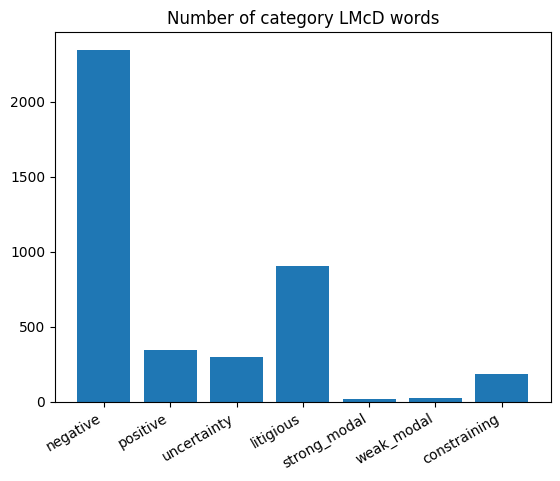

In [5]:
fig, ax = plt.subplots()
labels = list(lmcd_dict.keys())
values = [len(lmcd_dict[word]) for word in labels]
ax.bar(x = labels, height = values)
ax.set_xticks(labels)
ax.set_xticklabels(labels, rotation = 30, ha = "right")
ax.set_title("Number of category LMcD words")
plt.show()

Below you can examine the development of word category frequencies for Apple 's 10-K filings. We can observe how the number of negative and litigious words rise during the great financial crisis. 

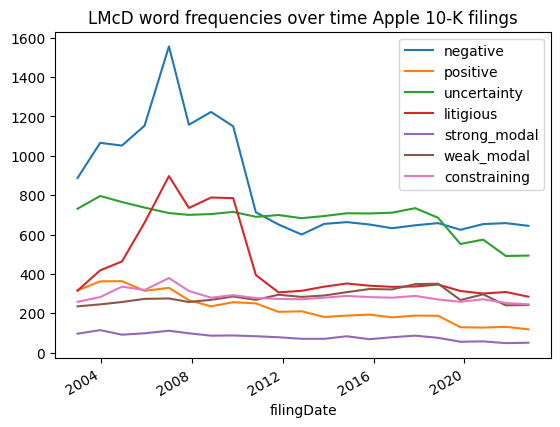

In [35]:
for i, report in enumerate(apple_filings.text):
    processed_report = simple_preprocess(report)
    if i == 0:
        lmcd_frequencies = dict_word_vectorizer(lmcd_dict, processed_report, raw_counts=False, normalize=False)
    else:
        lmcd_frequencies = pd.concat((lmcd_frequencies, dict_word_vectorizer(lmcd_dict, processed_report, raw_counts=False, normalize=False)))

lmcd_words_over_time = pd.DataFrame(data = lmcd_frequencies.values, index = pd.to_datetime(apple_filings.filingDate), columns = lmcd_frequencies.columns)
lmcd_words_over_time.plot(title = "LMcD word frequencies over time Apple 10-K filings")
plt.show()

## Polarity

Sometimes the occurrence of positive and negative words is translated into polarity. Polarity is the number of positive words minus the number of negative words divided by the overall number of positive and negative words.

$$
polarity = \frac{n^{positive} - n^{negative}}{n^{positive} + n^{negative}}
$$

See below how drastically the polarity of Apple's 10-K filings is impacted by the choice of the dictionary defining positive and negative words. We observe how the polarity decreases during the great financial crisis when using the dictionary by Loughran and McDonald (2011). In comparison, polarity does not decrease when using the general purpose Harvard IV-4 dictionary. This already indicates that domain-specific language modeling may be important for financial documents. 

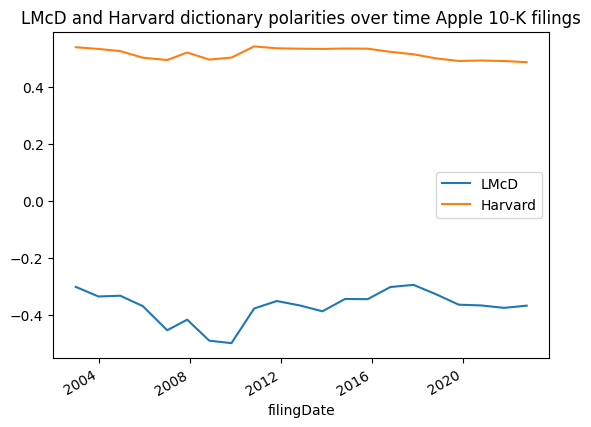

In [36]:
hv = ps.HIV4()
lm = ps.LM()

lm_polarity = []
hv_polarity = []

for report in apple_filings.text:
    lm_tokens = lm.tokenize(report)
    hv_tokens = hv.tokenize(report)
    lm_score = lm.get_score(lm_tokens)
    hv_score = hv.get_score(hv_tokens)
    lm_polarity.append(lm_score["Polarity"])
    hv_polarity.append(hv_score["Polarity"])

lmcd_harvard_polarity = pd.DataFrame([lm_polarity, hv_polarity], columns = pd.to_datetime(apple_filings.filingDate), index = ["LMcD", "Harvard"]).transpose()
lmcd_harvard_polarity.plot(title = "LMcD and Harvard dictionary polarities over time Apple 10-K filings")
plt.show()

## Similarity measures

Often, we want to quantify how similar document vectors are. This can be done by distance metrics of vectors. Popular choices are, e.g., the euclidean distance or cosine similarity. Given the document vectors $\boldsymbol{x}_i$ and $\boldsymbol{x}_k$, the euclidean distance is defined by:

$$
d_{euclidean}\left( \boldsymbol{x}_i, \boldsymbol{x}_k \right) = \sqrt{ \sum_{j=1}^{d} \left(x_{ij} - x_{kj} \right)^2} = ||\boldsymbol{x}_i - \boldsymbol{x}_k||
$$

The lower this value, the more close the document vectors are to each other, the more similar they should be. Cosine similarity is defined by:

$$
d_{cosine} (\boldsymbol{x}_i, \boldsymbol{x}_{k}) = \frac{\sum_{j = 1}^d  x_{ij} x_{kj}}{\sqrt{ \sum_{j = 1}^d x_{ij}^2} \sqrt{ \sum_{j = 1}^d x_{kj}^2}} = \frac{\boldsymbol{x}_i \cdot \boldsymbol{x}_k}{|| \boldsymbol{x}_i || || \boldsymbol{x}_k ||}
$$

It measures the angle between vectors and can have values in the range $[-1, 1]$. If each vector has only non-negative values, its range is in $[0, 1]$. The smaller the angle between the vectors, the higher the value for cosine similarity. 

Both measures can suffer in high-dimensional spaces, meaning if vectors have a high dimension. However, cosine similarity is often favored for text analysis, if it includes sparse vectors. Sparse vectors have many $0$ entries which have no impact on the distance measure (as the product in the numerator is always zero for this position). A [popular paper](https://onlinelibrary.wiley.com/doi/10.1111/jofi.12885) in the Journal of Finance by Cohen at al. (2020) finds that bigger changes in 10-K filings indicate a decline in the company's stock price. With this in mind, let us examine euclidean distances and cosine distances (1 - $d_{cosine}$) for the Apple filings.

## The curse of dimensionality

In this context we quickly should discuss the curse of dimensionality and its impact on measuring similarities between numerical representations of documents. In general, the volume of numerical spaces rises quickly if its dimension increases. A side-effect of this increase is that observations tend be drawn away from each other and the data becomes more sparse. If data is sparse, it becomes more challenging to identify similarities and dissimilarities between observations. Identifying such similarities and dissimilarities are in the center of supervised and unsupervised machine learning algorithms, such as clustering, regression or classification tasks. 

However, the exact impact for increasing dimensionality depends on the numerical space and the task itself. Let us take a look at some examples to get some intuition thouth. First, let us understand what it means the numerical space quickly increases. Assume, we identify the state of an observation by binary $x_i \in \lbrace 0, 1 \rbrace \forall x_i$ variables. If we use one variable $x_1$ (one dimension), the number of possible states is $2$, i.e., $(0), (1)$, if we use two variables (two dimensions), the number of possible states is $4$, i.e., 

$$
\begin{pmatrix}
0 \\
0 \\
\end{pmatrix}, 
\begin{pmatrix}
0 \\
1 \\
\end{pmatrix},
\begin{pmatrix}
1 \\
0 \\
\end{pmatrix}
\begin{pmatrix}
1 \\
1 \\
\end{pmatrix}
$$

if we use three variables (three dimensions), the number of possible states is $8$ and in general for $d$ dimensions, the number of possible states is $2^d$. The graph below illustrates that in this scenario the volume of the numerical space even increases exponentially for incrasing dimensions.

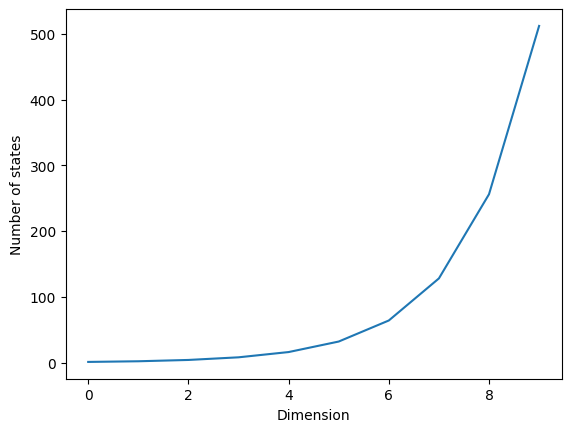

In [114]:
x = list(range(10))
y = [2**i for i in x]
plt.plot(x, y)
plt.xlabel("Dimension")
plt.ylabel("Number of states")
plt.show()

To get a intuition for observations being drawn apart in higher dimensions and how this depends on the numerical space and the measure which is used for quantifying the distance between observations, let us take a look at some simulation experiments. The first assumes each observation is in the interval $x_i \in [0, 1] \forall x_i$. For a given dimension each vector $\boldsymbol{x}^T = \begin{pmatrix} x_{i1} & ... & x_{id} \end{pmatrix} $ is located in the the vector space $[0, 1]^d$. We randomly draw $n$ observations in the vector space with uniform probabilities (each position is equally likely) and (1) calculate the average of all pairwise euclidean and cosine distances. For instance, the next to cells exhibit this for $n = 500$ and $d = 2, 3$.

The average euclidean distance is: 0.5266
The average cosine distance is: 0.1646


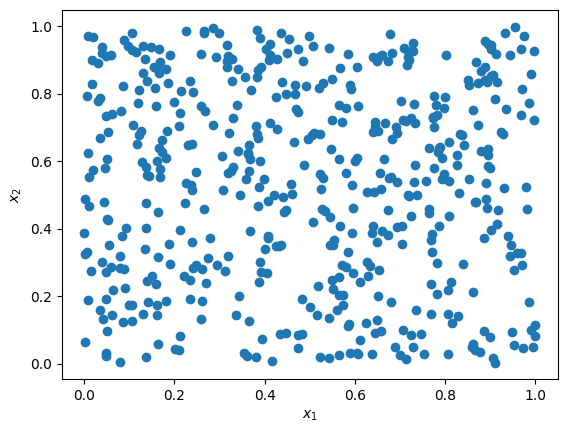

In [117]:
n = 500
U = np.random.rand(n, 2)
plt.scatter(U[:, 0], U[:, 1])
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
euc_dist = euclidean_distances(U)
cos_dist = cosine_distances(U)
euc_dist_flatten = euc_dist[np.tril_indices(n, k = -1)]
cos_dist_flatten = cos_dist[np.tril_indices(n, k = -1)]
print(f"The average euclidean distance is: {np.mean(euc_dist_flatten):.4f}")
print(f"The average cosine distance is: {np.mean(cos_dist_flatten):.4f}")

The average euclidean distance is: 0.6716
The average cosine distance is: 0.2062


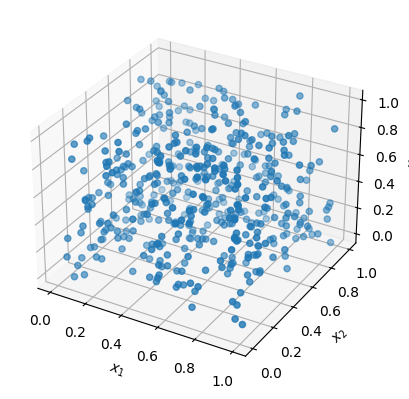

In [120]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

U = np.random.rand(n, 3)
ax.scatter(U[:, 0], U[:, 1], U[:, 2])
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel(r"$x_3$")
euc_dist = euclidean_distances(U)
cos_dist = cosine_distances(U)
euc_dist_flatten = euc_dist[np.tril_indices(n, k = -1)]
cos_dist_flatten = cos_dist[np.tril_indices(n, k = -1)]
print(f"The average euclidean distance is: {np.mean(euc_dist_flatten):.4f}")
print(f"The average cosine distance is: {np.mean(cos_dist_flatten):.4f}")

Now let us take a look, this the average distances behave for an increasing number of dimensions. The cell below exhibits the distance distributions for $d = 10, 100, 1000$. We observe that distributions are shifted to the right for pairwise euclidean distances which means they increase simply because we increase dimensionality. The cosine distances stay on average at the same level, but, become less diverse with increasing dimensionality. Does this mean that cosine similariy is not prone to the fallacies of the curse of dimensionality?

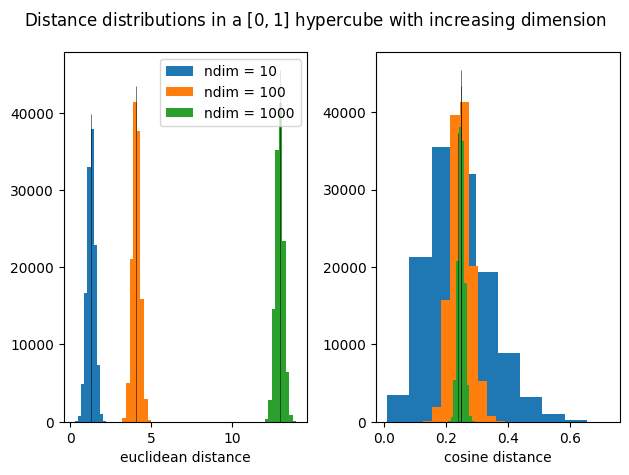

In [129]:
n = 500
n_dims = [10, 100, 1000]

fig, axs = plt.subplots(1, 2)

for i, n_dim in enumerate(n_dims):
    U = np.random.rand(n, n_dim)
    euc_dist = euclidean_distances(U)
    cos_dist = cosine_distances(U)
    euc_dist_flatten = euc_dist[np.tril_indices(n, k = -1)]
    cos_dist_flatten = cos_dist[np.tril_indices(n, k = -1)]

    axs[0].hist(euc_dist_flatten, label = f"ndim = {n_dim}", density = False)
    axs[0].vlines(np.mean(euc_dist_flatten), axs[0].get_ylim()[0], axs[0].get_ylim()[1], color = "k", linewidth = 0.5, alpha = 0.75)
    axs[0].set_xlabel("euclidean distance")
    axs[1].hist(cos_dist_flatten)
    axs[1].vlines(np.mean(cos_dist_flatten), axs[1].get_ylim()[0], axs[1].get_ylim()[1], color = "k", linewidth = 0.5, alpha = 0.75)
    axs[1].set_xlabel("cosine distance")

axs[0].legend()

fig.suptitle(rf"Distance distributions in a $[0, 1]$ hypercube with increasing dimension")
fig.tight_layout()

 Unfortunately not in general! Take a look a look at the cell below for which we now sample observations in $[-1, 1]^d$.

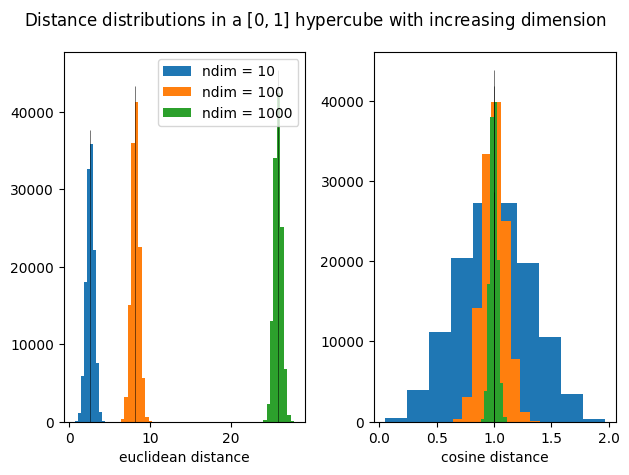

In [130]:
n = 500
n_dims = [10, 100, 1000]

fig, axs = plt.subplots(1, 2)

for i, n_dim in enumerate(n_dims):
    U = np.random.uniform(-1, 1, size = n * n_dim).reshape(n, n_dim)
    euc_dist = euclidean_distances(U)
    cos_dist = cosine_distances(U)
    euc_dist_flatten = euc_dist[np.tril_indices(n, k = -1)]
    cos_dist_flatten = cos_dist[np.tril_indices(n, k = -1)]

    axs[0].hist(euc_dist_flatten, label = f"ndim = {n_dim}", density = False)
    axs[0].vlines(np.mean(euc_dist_flatten), axs[0].get_ylim()[0], axs[0].get_ylim()[1], color = "k", linewidth = 0.5, alpha = 0.75)
    axs[0].set_xlabel("euclidean distance")
    axs[1].hist(cos_dist_flatten)
    axs[1].vlines(np.mean(cos_dist_flatten), axs[1].get_ylim()[0], axs[1].get_ylim()[1], color = "k", linewidth = 0.5, alpha = 0.75)
    axs[1].set_xlabel("cosine distance")

axs[0].legend()

fig.suptitle(rf"Distance distributions in a $[0, 1]$ hypercube with increasing dimension")
fig.tight_layout()

Remember that cosine distance is $ 1 - d_{cosine} (\boldsymbol{x}_i, \boldsymbol{x}_{k})$, this means that an average value of it being equal to $1$ implies average similarities of $0$. Thus, for higher dimension, vectors are independent of each other. Let us end the experiment here. What you should take away from it is that measuring similarities can become challenging if we use high dimensional vectors for the numerical representation of words and documents. Thus, sometimes we may need to bring high-dimensional representations back to lower dimensions by making use of dimensionality reduction techniques as principal component analysis (PCA), t-distributed neighbor embedding (t-sne) or unifold manifold approximation and projection (umap).